In [1]:
# STEP 1: basic setup 


!pip install -q numpy matplotlib rasterio 
!pip install tqdm
!pip install geopandas
!pip install torch

import sys, platform
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())

#import numpy as np

#import matplotlib.pyplot as plt
#import rasterio
#from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler


print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.7 MB 11.6 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.7 MB 11.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 11.7 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.7 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---- ----------------------------------- 2.4/22.9 MB 11.8 MB/s eta 0:00:02
   -------- ------------------------------- 4.7/22.9 MB 11.8 MB/s eta 0:00:02
   ------------ --------------------------- 7.1/22.9 MB 11.8 MB/s eta 0:00:02
   ---------------- ----------------------- 9.4/22.9 MB 11.8 MB/s eta 0:00:02
   -------------------- ------------------- 11.8/22.9 MB 11.8 MB/s eta 0:00:01
   ------------------------ --------------- 14.2/22.9 MB 11.8 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
    --------------------------------------- 2.1/114.6 MB 11.3 MB/s eta 0:00:10
   - -------------------------------------- 4.7/114.6 MB 11.6 MB/s eta 0:00:10
   -- ------------------------------------- 7.1/114.6 MB 11.7 MB/s eta 0:00:10
   --- ------------------------------------ 9.7/114.6 MB 11.7 MB/s eta 0:00:09
   ---- ----------------------------------- 12.1/114.6 MB 11.7 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/114.6 MB 11.7 MB/s eta 0:00:09
   ----- ---------------------------------- 16.8/114.6 MB 11.8 MB/s eta 0:00:09
   ------ --------------------------------- 19.1/114.6 MB 11.8 MB/s eta 0:00:09
   ------- -------------------------------- 21.5/114.6 MB 11.8 MB/s eta 0:00:08
   -------- ------------------------------- 24.1/114.6 MB 11.8 MB/s eta 0:00:08
   --------- ------------------------------ 26.5/114.6 MB 11.8 MB/s eta 0:00:08
   ---------- ----------------------------- 29.1/114.

Dataset Splitting

In [2]:
# STEP 2 – Dataset based on 2 km .npy patches + checkerboard spatial split (NO DEM)
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# -------------------------------------------------------------------
# 1) Paths & load metadata
# -------------------------------------------------------------------
PATCH_ROOT = Path(r"D:\Sunita_Thesis\Datasets\Data_Patches_2km_noDEM")
META_PATH  = PATCH_ROOT / "patch_metadata_with_order.csv"  # your file

meta = pd.read_csv(META_PATH, sep=";")
print("Metadata columns:", meta.columns.tolist())
print("Total patches:", len(meta))

# -------------------------------------------------------------------
# 2) Build normalized grid indices (grid_row, grid_col)
# -------------------------------------------------------------------
rows_sorted = sorted(meta["row"].unique(), reverse=True)  # north→south
cols_sorted = sorted(meta["col"].unique())               # west→east

row_to_grid = {r: i for i, r in enumerate(rows_sorted)}
col_to_grid = {c: j for j, c in enumerate(cols_sorted)}

meta["grid_row"] = meta["row"].map(row_to_grid)
meta["grid_col"] = meta["col"].map(col_to_grid)

print("Grid size (in patches):",
      meta["grid_row"].max() + 1, "rows x",
      meta["grid_col"].max() + 1, "cols")

# -------------------------------------------------------------------
# 3) Checkerboard-style spatial split (≈70/15/15)
# -------------------------------------------------------------------
BLOCK = 4  

block_row = meta["grid_row"] // BLOCK
block_col = meta["grid_col"] // BLOCK
gid = (block_row + block_col) % 7  # 0..6

def assign_split_from_gid(g):
    if g in {0, 1, 2, 3, 4}:
        return "train"
    elif g == 5:
        return "val"
    else:
        return "test"
        
meta["split"] = gid.apply(assign_split_from_gid)

OUT_META = PATCH_ROOT / "patch_metadata_checkerboard.csv"
meta.to_csv(OUT_META, sep=";", index=False)

print("Saved checkerboard metadata to:", OUT_META)

print("Split counts:")
print(meta["split"].value_counts())
print("Split ratios:",
      (meta["split"].value_counts() / len(meta)).round(3))


Metadata columns: ['order_id', 'patch_idx', 'filename', 'col', 'row', 'ulx', 'uly']
Total patches: 38795
Grid size (in patches): 229 rows x 347 cols
Saved checkerboard metadata to: D:\Sunita_Thesis\Datasets\Data_Patches_2km_noDEM\patch_metadata_checkerboard.csv
Split counts:
split
train    27723
val       5558
test      5514
Name: count, dtype: int64
Split ratios: split
train    0.715
val      0.143
test     0.142
Name: count, dtype: float64


Visualization of splitted tiles

In [ ]:
#Visualization

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Load metadata 
PATCH_ROOT = Path(r"D:\Sunita_Thesis\Datasets\Data_Patches_2km_noDEM")
META_PATH  = PATCH_ROOT / "patch_metadata_checkerboard.csv"

meta = pd.read_csv(META_PATH, sep=";")

# Build grid indices again
rows_sorted = sorted(meta["row"].unique(), reverse=True)
cols_sorted = sorted(meta["col"].unique())

row_to_grid = {r: i for i, r in enumerate(rows_sorted)}
col_to_grid = {c: j for j, c in enumerate(cols_sorted)}

meta["grid_row"] = meta["row"].map(row_to_grid)
meta["grid_col"] = meta["col"].map(col_to_grid)

# Use the 'split' column from your checkerboard split
splits = meta["split"].values

# Map split → color
color_map = {
    "train": "#3cb44b",   # green
    "val":   "#4363d8",   # blue
    "test":  "#e6194B",   # red
}

colors = [color_map[s] for s in splits]

# Figure size scaling based on grid size
nrows = meta["grid_row"].max() + 1
ncols = meta["grid_col"].max() + 1
aspect_ratio = ncols / nrows

plt.figure(figsize=(14 * aspect_ratio, 14))

# Scatter plot each tile as a small square
plt.scatter(
    meta["grid_col"],
    meta["grid_row"],
    c=colors,
    s=10,          # smaller = cleaner for big maps
    marker="s"     # square marker = patch shape
)

plt.gca().invert_yaxis()           # north at top
plt.gca().set_aspect('equal')      # square pixels

plt.title("Checkerboard Spatial Split: Train / Val / Test", fontsize=16)
plt.xlabel("Grid Column (west → east)")
plt.ylabel("Grid Row (north → south)")

# Create legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=color_map["train"], label="Train (~70%)"),
    mpatches.Patch(color=color_map["val"],   label="Validation (~15%)"),
    mpatches.Patch(color=color_map["test"],  label="Test (~15%)"),
]
plt.legend(handles=legend_handles, loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()


Dataloaders

In [ ]:
from pathlib import Path
import numpy as np
import torch
import random
from torch.utils.data import Dataset, DataLoader

# ============================================================
# 0) PATHS & CHANNELS
# ============================================================
PATCH_ROOT = Path(r"D:\Sunita_Thesis\Datasets\Data_Patches_2km_noDEM")

# Inputs = R,G,B,NIR 
INPUT_CHANNELS = [0, 1, 2, 3]   # [R, G, B, NIR]
TARGET_CHANNEL = 4              # [NOISE]
TARGET_NODATA = 0            
MASK_ZERO_TARGET=False

# Checkpoint folder (auto-create)
#RUN_DIR = PATCH_ROOT / "runs_unet_nodem_Augmented"
#UN_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1) STATS FUNCTIONS (DEFINE FIRST)
# ============================================================
@torch.no_grad()
def compute_input_stats(loader, device="cpu"):
    """
    Computes per-channel mean/std for x over the RAW TRAIN set only.
    Expects loader yielding (x,y,mask,info) with x shape (B,C,H,W)
    """
    n_channels = None
    total_sum = None
    total_sumsq = None
    total_count = 0

    for x, y, mask, info in loader:
        x = x.to(device, non_blocking=True)


        if n_channels is None:
            n_channels = x.shape[1]
            total_sum = torch.zeros(n_channels, device=device)
            total_sumsq = torch.zeros(n_channels, device=device)

        b, c, h, w = x.shape
        total_sum += x.sum(dim=(0, 2, 3))
        total_sumsq += (x * x).sum(dim=(0, 2, 3))
        total_count += b * h * w

    mean = total_sum / total_count
    var = (total_sumsq / total_count) - mean**2
    std = torch.sqrt(torch.clamp(var, min=1e-12))
    return mean.cpu(), std.cpu()


@torch.no_grad()
def compute_target_stats_valid(loader, device="cpu"):
    """
    Computes mean/std for y over VALID pixels only (mask==1).
    y, mask shape: (B,1,H,W)
    """
    total_sum = torch.tensor(0.0, device=device)
    total_sumsq = torch.tensor(0.0, device=device)
    total_count = torch.tensor(0.0, device=device)

    for x, y, mask, info in loader:
        y = y.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        valid = mask > 0.5
        yv = y[valid]
        if yv.numel() == 0:
            continue

        total_sum += yv.sum()
        total_sumsq += (yv * yv).sum()
        total_count += yv.numel()

    mean = total_sum / total_count
    var = (total_sumsq / total_count) - mean**2
    std = torch.sqrt(torch.clamp(var, min=1e-12))
    return mean.item(), std.item(), total_count.item()


# ============================================================
# 2) MASK FUNCTION + DATASET
# ============================================================
def build_target_mask(y_np: np.ndarray, nodata_value=None) -> np.ndarray:
    """
    y_np: (1,H,W) float32
    returns mask: (1,H,W) float32, 1=valid, 0=nodata
    """
    mask = np.isfinite(y_np)

    if nodata_value is not None:
        mask = mask & (y_np != nodata_value)

    # extra safety for extreme negative sentinels 
    mask = mask & (y_np > -1e6)

    if MASK_ZERO_TARGET:
        mask= mask & (y_np != 0.0)
    return mask.astype("float32")


class NpyPatchDataset(Dataset):
    """
    Each .npy: (6,200,200) = [DEM, R, G, B, NIR, NOISE]
    Returns:
      x: (4,200,200) normalized if x_mean/x_std provided
      y: (1,200,200) with nodata filled to 0 (mask excludes it)
      mask: (1,200,200) 1 valid, 0 nodata
      info: string id
    """
    def __init__(self, meta_df, split: str, root: Path,
                 target_nodata=None, x_mean=None, x_std=None, augment=False):
        self.root = root
        self.meta = meta_df[meta_df["split"] == split].reset_index(drop=True)
        self.split = split
        self.target_nodata = target_nodata

        self.x_mean = x_mean
        self.x_std = x_std
        self.augment=augment

        print(f"{split}: {len(self.meta)} patches| augment={self.augment}")

    def __len__(self):
        return len(self.meta)

    @staticmethod
    def _apply_augmentations(x, y, mask):
        """
        x: (C,H,W), y: (1,H,W), mask: (1,H,W)
        Applies the same random augmentations to all three.
        """
        # 1) Random Horizontal Flip (p=0.5)
        if random.random() < 0.5:
            x = torch.flip(x, dims=[2])      # flip W
            y = torch.flip(y, dims=[2])
            mask = torch.flip(mask, dims=[2])
    
        # 2) Random Vertical Flip (p=0.5)
        if random.random() < 0.5:
            x = torch.flip(x, dims=[1])      # flip H
            y = torch.flip(y, dims=[1])
            mask = torch.flip(mask, dims=[1])
    
        # 3) Random Rotation (p=1/3) rotate by 90/180/270
        if random.random() < (1.0/3.0):
            k = random.choice([1, 2, 3])     # 1=90, 2=180, 3=270
            x = torch.rot90(x, k=k, dims=[1, 2])
            y = torch.rot90(y, k=k, dims=[1, 2])
            mask = torch.rot90(mask, k=k, dims=[1, 2])
    
        return x, y, mask
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        path = self.root / row["filename"]
        arr = np.load(path)  # (6,200,200)

        x = arr[INPUT_CHANNELS].astype("float32")  # (4,200,200)
        y = arr[TARGET_CHANNEL:TARGET_CHANNEL+1].astype("float32")  # (1,200,200)

        mask = build_target_mask(y, nodata_value=self.target_nodata)

        y_filled = y.copy()
        y_filled[mask == 0] = 0.0      

        x = torch.from_numpy(x)
        y_filled = torch.from_numpy(y_filled)
        mask = torch.from_numpy(mask)

        # ✅ augment only for train
        if self.augment:
            x, y_filled, mask = self._apply_augmentations(x, y_filled, mask)

        # Apply normalization if provided (train stats)
        if self.x_mean is not None and self.x_std is not None:
            mean = self.x_mean.view(-1, 1, 1)
            std = self.x_std.view(-1, 1, 1).clamp_min(1e-6)
            x = (x - mean) / std

        info = f"id={int(row['order_id'])}_col={row['col']}_row={row['row']}"
        return x, y_filled, mask, info


import numpy as np

def filter_meta_by_valid_frac(
    meta,
    patch_root,
    target_channel,
    nodata_value=None,
    min_valid_frac=0.05
):
    """
    Removes patches where fraction of VALID target pixels (after mask rules) is < min_valid_frac.
    """
    keep_rows = []

    for _, row in meta.iterrows():
        arr = np.load(patch_root / row["filename"])
        y = arr[target_channel:target_channel+1].astype("float32")  # (1,H,W)

        mask = build_target_mask(y, nodata_value=nodata_value)  # SAME rule as training
        frac = float(mask.mean())

        keep_rows.append(frac >= min_valid_frac)

    return meta.loc[keep_rows].reset_index(drop=True)

MIN_VALID_FRAC = 0.05  # start here

meta_filtered = filter_meta_by_valid_frac(
    meta,
    PATCH_ROOT,
    target_channel=TARGET_CHANNEL,
    nodata_value=TARGET_NODATA,
    min_valid_frac=MIN_VALID_FRAC
)

print("After filtering:")
print(meta_filtered["split"].value_counts())
meta= meta_filtered


# ============================================================
# 3) RAW TRAIN LOADER FOR INPUT STATS (NO NORMALIZATION)
# ============================================================
BATCH_SIZE_STATS = 4

train_ds_raw = NpyPatchDataset(
    meta_filtered, "train", PATCH_ROOT,
    target_nodata=TARGET_NODATA,
    x_mean=None, x_std=None,
    augment=False,
)

train_loader_raw = DataLoader(
    train_ds_raw,
    batch_size=BATCH_SIZE_STATS,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Compute stats on RAW train only
x_mean, x_std = compute_input_stats(train_loader_raw, device="cpu")
print("RAW train input mean (R,G,B,NIR):", x_mean.numpy())
print("RAW train input std  (R,G,B,NIR):", x_std.numpy())

x_mean_t = x_mean.float()
x_std_t = x_std.float()
np.savez(str(RUN_DIR / "x_stats.npz"),
         x_mean=x_mean_t.cpu().numpy(),
         x_std=x_std_t.cpu().numpy())
print("Saved stats to:", RUN_DIR / "x_stats.npz")

# ============================================================
# 4) NORMALIZED TRAIN/VAL/TEST DATASETS + LOADERS
# ============================================================
BATCH_SIZE = 4

train_ds = NpyPatchDataset(meta_filtered, "train", PATCH_ROOT, target_nodata=TARGET_NODATA,
                           x_mean=x_mean_t, x_std=x_std_t, augment=True)
val_ds   = NpyPatchDataset(meta_filtered, "val",   PATCH_ROOT, target_nodata=TARGET_NODATA,
                           x_mean=x_mean_t, x_std=x_std_t, augment=False)
test_ds  = NpyPatchDataset(meta_filtered, "test",  PATCH_ROOT, target_nodata=TARGET_NODATA,
                           x_mean=x_mean_t, x_std=x_std_t, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# ============================================================
# 5) SANITY CHECKS
# ============================================================
x, y, m, info = next(iter(train_loader))
print("\nSanity check (normalized loader):")
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)
print("mask:", m.shape, m.dtype)
print("info[0]:", info[0])
print("valid pixel ratio (batch):", (m.sum() / m.numel()).item())
print("x mean per channel (batch):", x.mean(dim=(0,2,3)))
print("x std  per channel (batch):", x.std(dim=(0,2,3)))

# Optional: target stats (valid pixels only) using normalized loader (fine)
y_mean, y_std, y_n = compute_target_stats_valid(train_loader, device="cpu")
print(f"\nTarget mean/std over valid pixels: {y_mean:.3f} / {y_std:.3f} (N={int(y_n)})")


Sanity check block below

In [ ]:
x, y, m, info = train_ds[0]

print("Valid pixel ratio:", m.mean().item())
print("Zeros in VALID pixels:",
      (y[m > 0.5] == 0).float().mean().item())
print("Zeros in ALL pixels:",
      (y == 0).float().mean().item())


In [ ]:
import numpy as np

def compute_valid_fraction_per_patch(meta, split, root, target_channel=4, min_positive=1):
    sub = meta[meta["split"] == split].reset_index(drop=True)
    fracs = []
    all_zero = 0

    for i in range(len(sub)):
        arr = np.load(root / sub.loc[i, "filename"])
        y = arr[target_channel].astype(np.float32)  # (H,W)

        valid = (np.isfinite(y)) & (y > 0.0)  # your new masking rule
        n_valid = int(valid.sum())
        frac = n_valid / valid.size
        fracs.append(frac)

        if n_valid < min_positive:
            all_zero += 1

    fracs = np.array(fracs)
    print(f"[{split}] patches: {len(fracs)}")
    print(f"[{split}] patches with <{min_positive} valid pixels (basically empty): {all_zero} ({all_zero/len(fracs)*100:.2f}%)")
    print(f"[{split}] valid fraction stats: min={fracs.min():.4f}, mean={fracs.mean():.4f}, max={fracs.max():.4f}")
    return fracs

train_fracs = compute_valid_fraction_per_patch(meta, "train", PATCH_ROOT)
val_fracs   = compute_valid_fraction_per_patch(meta, "val",   PATCH_ROOT)
test_fracs  = compute_valid_fraction_per_patch(meta, "test",  PATCH_ROOT)


Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Building blocks
# -----------------------------

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None, p_drop=0.0):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity(),

            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels, p_drop=0.0):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, p_drop=p_drop),
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True, p_drop=0.0):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, mid_channels=in_channels // 2, p_drop=p_drop)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels, p_drop=p_drop)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diffX // 2, diffX - diffX // 2,
                diffY // 2, diffY - diffY // 2,
            ],
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """Final 1x1 conv (linear output for regression)"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net for regression.
    - n_channels: input channels (NOW: 5 with DEM excluded)
    - n_classes: output channels (1 noise map)
    """
    def __init__(self, n_channels, n_classes, bilinear=False, p_drop_shallow=0.0,p_drop_deep=0.2):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64, p_drop=p_drop_shallow)
        self.down1 = Down(64, 128, p_drop=p_drop_shallow)
        self.down2 = Down(128, 256, p_drop=p_drop_deep)
        self.down3 = Down(256, 512, p_drop=p_drop_deep)

        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor, p_drop=p_drop_deep)

        self.up1 = Up(1024, 512 // factor, bilinear, p_drop=p_drop_deep)
        self.up2 = Up(512, 256 // factor, bilinear, p_drop=p_drop_deep)
        self.up3 = Up(256, 128 // factor, bilinear, p_drop=p_drop_shallow)
        self.up4 = Up(128, 64, bilinear, p_drop=p_drop_shallow)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)


# -----------------------------
# Instantiate model (5 channels)
# -----------------------------

# Input tensor channels: [ R, G, B, NIR, NOISE] OR [R,G,B,NIR,NOISE]
IN_CHANNELS  = 4   # NO DEM: R,G,B,NIR
OUT_CHANNELS = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_channels=IN_CHANNELS, n_classes=OUT_CHANNELS, bilinear=False, p_drop_shallow=0.05, p_drop_deep=0.20).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: UNet (prof), parameters: {n_params/1e6:.3f} M, device: {device}")



# -----------------------------
# Sanity check
model.eval()
with torch.no_grad():
    batch = next(iter(train_loader))

    # Handles: (xb,yb,mask,info) OR (xb,yb,info) OR (xb,yb)
    if isinstance(batch, (tuple, list)) and len(batch) == 4:
        xb, yb, mask, info = batch
    elif isinstance(batch, (tuple, list)) and len(batch) == 3:
        xb, yb, info = batch
        mask = None
    elif isinstance(batch, (tuple, list)) and len(batch) == 2:
        xb, yb = batch
        mask, info = None, None
    else:
        raise RuntimeError(
            f"Unexpected batch format from train_loader: {type(batch)} / "
            f"len={len(batch) if hasattr(batch,'__len__') else 'NA'}"
        )

    xb = xb.to(device)
    yb = yb.to(device)
    if mask is not None:
        mask = mask.to(device)

    pred = model(xb)

    print("Input batch:", xb.shape)     # (B,4,H,W)
    print("Target batch:", yb.shape)    # (B,1,H,W)
    print("Pred batch:", pred.shape)    # (B,1,H,W)
    if mask is not None:
        print("Mask batch:", mask.shape)  # (B,1,H,W)

    assert xb.ndim == 4, f"Expected xb to be 4D (B,C,H,W), got {xb.ndim}D"
    assert xb.shape[1] == IN_CHANNELS, f"Expected {IN_CHANNELS} input channels, got {xb.shape[1]}"
    assert pred.shape[1] == OUT_CHANNELS, f"Expected {OUT_CHANNELS} output channel(s), got {pred.shape[1]}"
    assert pred.shape[2:] == yb.shape[2:], f"Pred spatial {pred.shape[2:]} must match target {yb.shape[2:]}"
    if mask is not None:
        assert mask.shape == yb.shape, f"Mask shape {mask.shape} must match target {yb.shape}"

print("✅ Sanity check passed.")



In [ ]:
# --- masked losses/metrics ---
def masked_mse(pred, target, mask, eps=1e-8):
    diff2 = (pred - target) ** 2
    diff2 = diff2 * mask
    denom = mask.sum().clamp_min(eps)
    return diff2.sum() / denom

@torch.no_grad()
def masked_rmse(pred, target, mask, eps=1e-8):
    return torch.sqrt(masked_mse(pred, target, mask, eps=eps))

@torch.no_grad()
def masked_mae(pred, target, mask, eps=1e-8):
    diff = (pred - target).abs() * mask
    denom = mask.sum().clamp_min(eps)
    return diff.sum() / denom

@torch.no_grad()
def masked_r2(pred, target, mask, eps=1e-8):
    valid = mask > 0.5
    y = target[valid]
    yhat = pred[valid]
    if y.numel() == 0:
        return torch.tensor(0.0, device=pred.device)

    y_mean = y.mean()
    sse = ((yhat - y) ** 2).sum()
    sst = ((y - y_mean) ** 2).sum().clamp_min(eps)
    return 1.0 - (sse / sst)


Model Training

In [ ]:
import os, json
from pathlib import Path
import torch
import numpy as np

# -------------------------
# CONFIG
# -------------------------
MAX_EPOCHS = 100
LR = 1e-4
WEIGHT_DECAY = 1e-4

# Early stopping on val RMSE
EARLY_STOP_PATIENCE = 15     # consecutive epochs without improvement
MIN_DELTA_RMSE = 5e-4        # improvement threshold

# Plotting schedule
PLOT_START_EPOCH = 20        # no plots before this epoch
PLOT_EVERY = 10               # after start, plot every N epochs

# Mixed precision
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
print("Device:", device, "| AMP (mixed precision):", use_amp)

# Checkpoint folder (auto-create)
RUN_DIR = PATCH_ROOT / "runs_unet_nodem_v2_dropout"
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RUN_DIR / "checkpoint_last.pt"
BEST_PATH = RUN_DIR / "checkpoint_best.pt"
HIST_PATH = RUN_DIR / "history.json"

print("Run dir:", RUN_DIR)
print("Last checkpoint:", CKPT_PATH)
print("Best checkpoint:", BEST_PATH)

def save_checkpoint(path, model, optimizer, scaler, epoch, best_val_rmse, history):
    payload = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "best_val_rmse": best_val_rmse,
        "history": history,
        "use_amp": use_amp,
    }
    if scaler is not None:
        payload["scaler_state"] = scaler.state_dict()

    torch.save(payload, path)

    # also keep a json history for quick inspection
    with open(HIST_PATH, "w") as f:
        json.dump(history, f, indent=2)

def load_checkpoint(path, model, optimizer=None, scaler=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optim_state" in ckpt:
        optimizer.load_state_dict(ckpt["optim_state"])
    if scaler is not None and "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])
    epoch = ckpt.get("epoch", 0)
    best_val_rmse = ckpt.get("best_val_rmse", float("inf"))
    history = ckpt.get("history", {})
    return epoch, best_val_rmse, history


In [ ]:
import matplotlib.pyplot as plt

# Deterministic selection
rng = np.random.default_rng(42)

N_SHOW = 10
train_fixed_idx = rng.choice(len(train_ds), size=min(N_SHOW, len(train_ds)), replace=False).tolist()
val_fixed_idx   = rng.choice(len(val_ds),   size=min(N_SHOW, len(val_ds)),   replace=False).tolist()

def denorm_rgb(x_norm, x_mean_t, x_std_t):
    """
    x_norm: (C,H,W) normalized tensor
    returns rgb image in numpy float, clipped for display
    Assumes channels are [R,G,B,NIR] and we display RGB from first 3.
    """
    # de-normalize
    x = x_norm.clone()
    mean = x_mean_t.view(-1,1,1).to(x.device)
    std  = x_std_t.view(-1,1,1).to(x.device)
    x = x * std + mean

    rgb = x[:3].permute(1,2,0).detach().cpu().numpy()  # (H,W,3)

    # Contrast stretch for display (robust)
    lo = np.percentile(rgb, 2, axis=(0,1), keepdims=True)
    hi = np.percentile(rgb, 98, axis=(0,1), keepdims=True)
    rgb = (rgb - lo) / (hi - lo + 1e-6)
    rgb = np.clip(rgb, 0, 1)
    return rgb

@torch.no_grad()
def visualize_fixed_samples(model, ds, fixed_indices, title, device, x_mean_t, x_std_t):
    model.eval()

    n = len(fixed_indices)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(fixed_indices):
        x, y, mask, info = ds[idx]
        xb = x.unsqueeze(0).to(device)

        pred = model(xb).squeeze(0).squeeze(0).detach().cpu().numpy()
        gt   = y.squeeze(0).detach().cpu().numpy()
        mnp  = mask.squeeze(0).detach().cpu().numpy()  # 1 valid, 0 invalid

        invalid = (mnp < 0.5)


        # Display GT + Error only where valid
        gt_disp = gt.copy()
        gt_disp[invalid] = np.nan

        err_disp = (pred - gt).copy()
        err_disp[invalid] = np.nan

        max_abs = np.nanmax(np.abs(err_disp))
        if np.isfinite(max_abs) and max_abs > 0:
            err_vmin, err_vmax = -max_abs, max_abs
        else:
            err_vmin, err_vmax = None, None

        # Pred: show FULL prediction, but overlay invalid region
        pr_disp = pred.copy()

         # Use same color scale for GT and Pred based on GT valid pixels
        valid_vals = gt[~invalid]
        if valid_vals.size > 0:
            vmin = np.nanpercentile(valid_vals, 2)
            vmax = np.nanpercentile(valid_vals, 98)
        else:
            vmin, vmax = None, None


        rgb = denorm_rgb(x, x_mean_t, x_std_t)

        axes[i,0].imshow(rgb)
        axes[i,0].set_title(f"RGB\n{info}")
        axes[i,0].axis("off")


      # --- GT ---
        im1 = axes[i, 1].imshow(gt_disp, vmin=vmin, vmax=vmax)
        axes[i, 1].set_title("GT Noise (valid only)")
        axes[i, 1].axis("off")
        plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)
    

      # --- Pred (full) + invalid overlay ---
        im2 = axes[i, 2].imshow(pr_disp, vmin=vmin, vmax=vmax)
        axes[i, 2].set_title("Pred Noise")
        axes[i, 2].axis("off")
        #axes[i, 2].imshow(invalid, alpha=0.25)  # overlay mask
        plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

        im3 = axes[i,3].imshow(err_disp, vmin=err_vmin, vmax=err_vmax)
        axes[i,3].set_title("(Pred - GT)")
        axes[i,3].axis("off")
        plt.colorbar(im3, ax=axes[i,3], fraction=0.046, pad=0.04)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_curves(history, start_epoch=PLOT_START_EPOCH):
    epochs = history["epoch"]

    def _plot_train_val(key_train, key_val, ylabel):
        plt.figure()
        plt.plot(epochs, history[key_train], label=key_train)
        plt.plot(epochs, history[key_val], label=key_val)
        plt.axvline(start_epoch, linestyle="--")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.legend()
        plt.tight_layout()
        plt.show()

    _plot_train_val("train_loss", "val_loss", "Masked MSE Loss")
    _plot_train_val("train_rmse", "val_global_rmse", "RMSE (dB)  [VAL = GLOBAL]")
    _plot_train_val("train_mae",  "val_global_mae",  "MAE (dB)   [VAL = GLOBAL]")
    _plot_train_val("train_r2",   "val_global_r2",   "R²         [VAL = GLOBAL]")


In [ ]:
import torch
from torch.amp import autocast, GradScaler
scaler = GradScaler() if (use_amp and device.type=="cuda") else None

import torch

def train_one_epoch(model, loader, optimizer, scaler, device, use_amp=True, grad_clip=1.0):
    model.train()
    use_amp = use_amp and (device.type == "cuda") and (scaler is not None)  # or keep your flag, but gate it
    
    # Global accumulators over VALID pixels
    sse = 0.0   # sum squared error
    sae = 0.0   # sum absolute error
    sy  = 0.0   # sum y
    sy2 = 0.0   # sum y^2
    n_valid = 0.0

    n_batches = 0  # (optional) only for debugging

    for xb, yb, mb, info in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        mb = mb.to(device, non_blocking=True)

        # Skip batches with no valid pixels
        valid = mb.sum().item()
        if valid < 1:
            continue

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with autocast("cuda"):
                pred = model(xb)
                loss = masked_mse(pred, yb, mb)
            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(xb)
            loss = masked_mse(pred, yb, mb)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        # ---- metrics accumulation (VALID pixels only) ----
        with torch.no_grad():
            pred_d = pred.detach()

            # Ensure mask broadcasts: mb is usually (B,1,H,W)
            m = (mb > 0)

            # Flatten only valid pixels
            yv = yb[m]
            pv = pred_d[m]

            diff = pv - yv

            sse += torch.sum(diff * diff).item()
            sae += torch.sum(torch.abs(diff)).item()

            sy  += torch.sum(yv).item()
            sy2 += torch.sum(yv * yv).item()

            n_valid += yv.numel()
            n_batches += 1

    # If everything got skipped 
    if n_valid < 1:
        return {"loss": float("nan"), "rmse": float("nan"), "mae": float("nan"), "r2": float("nan")}

    mse = sse / n_valid
    rmse = (mse ** 0.5)
    mae = sae / n_valid

    # Global R^2
    # SST = sum((y - mean_y)^2) = sum(y^2) - n*mean_y^2
    mean_y = sy / n_valid
    sst = sy2 - n_valid * (mean_y ** 2)
    r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")

    return {"loss": mse, "rmse": rmse, "mae": mae, "r2": r2}


@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()

    sse = 0.0
    sae = 0.0
    sy  = 0.0
    sy2 = 0.0
    n_valid = 0.0

    for xb, yb, mb, info in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        mb = mb.to(device, non_blocking=True)

        valid = mb.sum().item()
        if valid < 1:
            continue

        pred = model(xb)

        m = (mb > 0)
        yv = yb[m]
        pv = pred[m]

        diff = pv - yv
        sse += torch.sum(diff * diff).item()
        sae += torch.sum(torch.abs(diff)).item()

        sy  += torch.sum(yv).item()
        sy2 += torch.sum(yv * yv).item()

        n_valid += yv.numel()

    if n_valid < 1:
        return {"loss": float("nan"), "rmse": float("nan"), "mae": float("nan"), "r2": float("nan")}

    mse = sse / n_valid
    rmse = (mse ** 0.5)
    mae = sae / n_valid

    mean_y = sy / n_valid
    sst = sy2 - n_valid * (mean_y ** 2)
    r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")

    return {"loss": mse, "rmse": rmse, "mae": mae, "r2": r2}

@torch.no_grad()
def evaluate_global_pixelwise(model, loader, device, eps=1e-8, use_amp=False):
    model.eval()

    # pass 1: compute global y_mean
    y_sum, y_n = 0.0, 0.0
    for xb, yb, mb, info in loader:
        yb = yb.to(device, non_blocking=True)
        mb = mb.to(device, non_blocking=True)
        valid = mb > 0.5
        yv = yb[valid]
        if yv.numel() > 0:
            y_sum += yv.sum().item()
            y_n += yv.numel()
    y_mean = y_sum / max(y_n, 1.0)

    # pass 2: SSE / SAE / SST
    sse, sae, sst, n = 0.0, 0.0, 0.0, 0.0
    for xb, yb, mb, info in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        mb = mb.to(device, non_blocking=True)

        if use_amp and device.type == "cuda":
            with autocast("cuda"):
                pred = model(xb)
        else:
            pred = model(xb)

        valid = mb > 0.5
        yv = yb[valid]
        pv = pred[valid]
        if yv.numel() == 0:
            continue

        diff = pv - yv
        sse += (diff * diff).sum().item()
        sae += diff.abs().sum().item()
        sst += ((yv - y_mean) ** 2).sum().item()
        n += yv.numel()

    mse = sse / max(n, 1.0)
    rmse = mse ** 0.5
    mae = sae / max(n, 1.0)
    r2 = 1.0 - (sse / max(sst, eps))

    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2, "n_valid": int(n)}


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = GradScaler() if (use_amp and device.type == "cuda") else None

# history dict (for plotting + saving)


start_epoch = 1
best_val_rmse = float("inf")
epochs_no_improve = 0
history = {
    "epoch": [],
    "train_loss": [], "val_loss": [],
    "train_rmse": [], "val_rmse": [],
    "train_mae":  [], "val_mae":  [],
    "train_r2":   [], "val_r2":   [],
        # global val
    "val_global_rmse": [],
    "val_global_mae": [],
    "val_global_r2": [],
    "val_global_n": [],
}

print("🆕 Starting training (epoch 1)")

last_epoch_ran=0
for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, scaler, device, use_amp=use_amp, grad_clip=1.0)
    val_metrics   = validate_one_epoch(model, val_loader, device)
    # ✅ GLOBAL validation (pixel-wise) — stable
    
    val_global = evaluate_global_pixelwise(model, val_loader, device, use_amp=use_amp)


    last_epoch_ran = epoch

    # log
    history["epoch"].append(epoch)
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_global_rmse"].append(val_global["rmse"])

    history["train_rmse"].append(train_metrics["rmse"])
    history["val_rmse"].append(val_metrics["rmse"])
    history["val_global_mae"].append(val_global["mae"])

    history["train_mae"].append(train_metrics["mae"])
    history["val_mae"].append(val_metrics["mae"])
    history["val_global_r2"].append(val_global["r2"])

    history["train_r2"].append(train_metrics["r2"])
    history["val_r2"].append(val_metrics["r2"])
    history["val_global_n"].append(val_global["n_valid"])

    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
        f"train: loss={train_metrics['loss']:.4f}, rmse={train_metrics['rmse']:.3f}, mae={train_metrics['mae']:.3f}, r2={train_metrics['r2']:.3f} | "
        f"val: loss={val_metrics['loss']:.4f}, rmse={val_metrics['rmse']:.3f}, mae={val_metrics['mae']:.3f}, r2={val_metrics['r2']:.3f} | "
        f"VAL_GLOBAL: rmse={val_global['rmse']:.3f}, mae={val_global['mae']:.3f}, r2={val_global['r2']:.3f}"
    
        )

    # check improvement on val RMSE
    current_val_rmse = val_global["rmse"]   # ✅ use GLOBAL val rmse

    improved = (best_val_rmse - current_val_rmse) > MIN_DELTA_RMSE
    if improved:
        best_val_rmse = current_val_rmse
        epochs_no_improve = 0
        # save best
        save_checkpoint(BEST_PATH, model, optimizer, scaler, epoch, best_val_rmse, history)
    else:
        epochs_no_improve += 1

    # always save "last" checkpoint (resume)
    save_checkpoint(CKPT_PATH, model, optimizer, scaler, epoch, best_val_rmse, history)

    # Plotting rules:
    # - no plots before epoch 20
    # - after 20: plot every 5 epochs
    do_plot = (epoch >= PLOT_START_EPOCH) and (epoch % PLOT_EVERY == 0)

    if do_plot:
        print(f"\n📈 Plotting at epoch {epoch} (rule: start@{PLOT_START_EPOCH}, every {PLOT_EVERY})")
        plot_curves(history, start_epoch=PLOT_START_EPOCH)

        visualize_fixed_samples(
            model, train_ds, train_fixed_idx,
            title=f"TRAIN fixed samples @ epoch {epoch}",
            device=device, x_mean_t=x_mean_t, x_std_t=x_std_t
        )
        visualize_fixed_samples(
            model, val_ds, val_fixed_idx,
            title=f"VAL fixed samples @ epoch {epoch}",
            device=device, x_mean_t=x_mean_t, x_std_t=x_std_t
        )

    # Early stopping rule
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\n Early stopping: val RMSE didn't improve for {EARLY_STOP_PATIENCE} consecutive epochs.")
        break

# Always visualize the last epoch that ran (your requirement)
print(f"\n Training ended at epoch {last_epoch_ran}. Best val RMSE: {best_val_rmse:.3f}")
print("Visualizing last epoch results.")

plot_curves(history, start_epoch=PLOT_START_EPOCH)

visualize_fixed_samples(
    model, train_ds, train_fixed_idx,
    title=f"TRAIN fixed samples @ LAST epoch {last_epoch_ran}",
    device=device, x_mean_t=x_mean_t, x_std_t=x_std_t
)
visualize_fixed_samples(
    model, val_ds, val_fixed_idx,
    title=f"VAL fixed samples @ LAST epoch {last_epoch_ran}",
    device=device, x_mean_t=x_mean_t, x_std_t=x_std_t
)


Visualizing Test samples

In [ ]:

# ============================================================
# 2) Load BEST checkpoint 
# ============================================================
assert BEST_PATH.exists(), f"Best checkpoint not found: {BEST_PATH}"
_ = load_checkpoint(BEST_PATH, model, optimizer=None, scaler=None, map_location=device)
model = model.to(device)
model.eval()
print("Loaded BEST checkpoint:", BEST_PATH)

# ============================================================
# VISUALIZE SPECIFIC PATCH FILENAMES (no training changes)
# ============================================================

import pandas as pd
from pathlib import Path

# ---------- 1) Your "Place <-> patch filename" CSV ----------
PLACE_CSV = r"D:\Sunita_Thesis\known_places_patch1_only.csv"  # <-- change if needed
place_df = pd.read_csv(PLACE_CSV)

def _norm_name(s):
    """Normalize any path/filename to just 'name.npy' with no spaces."""
    return Path(str(s)).name.strip()

# Build mapping: filename -> Place
# CSV columns expected: "Place" and "patch_1"
filename_to_place = dict(
    zip(
        place_df["patch_1"].astype(str).apply(_norm_name),
        place_df["Place"].astype(str).str.strip()
    )
)

# ---------- 2) Your selected patches (filenames only) ----------
patch_filenames = [
    "17249_col2681_row1248_x463110_y5248260.npy",
    "17598_col2682_row1247_x464090_y5247240.npy",
    "13771_col2683_row1258_x465310_y5258210.npy",
    "30109_col2665_row1211_x446380_y5211600.npy",
    "27965_col2609_row1217_x390530_y5218710.npy",
    "23566_col2734_row1230_x515720_y5229220.npy",
    "44730_col2670_row1169_x450550_y5169530.npy",
    "28989_col2589_row1214_x370480_y5216110.npy",
]

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def _norm_name(s):
    return Path(str(s)).name.strip()

def find_in_any_split(filename, train_ds, val_ds, test_ds):
    """Return (ds, idx, split_name) for the first split containing filename, else (None,None,None)."""
    key = _norm_name(filename)

    for split_name, ds in [("TRAIN", train_ds), ("VAL", val_ds), ("TEST", test_ds)]:
        ds_keys = ds.meta["filename"].astype(str).apply(_norm_name).tolist()
        # build map once per call (fine for a handful of patches)
        name_to_idx = {k: i for i, k in enumerate(ds_keys)}
        if key in name_to_idx:
            return ds, name_to_idx[key], split_name

    return None, None, None


@torch.no_grad()
def visualize_named_patches_any_split(
    model, train_ds, val_ds, test_ds,
    filenames,
    filename_to_place,
    title="Selected patches (prediction)",
    device=device,
    x_mean_t=x_mean_t, x_std_t=x_std_t
   
):
    """
    Shows one row per requested patch:
    RGB | DEM(meters) | GT(valid only) | Pred | Error
    Each row is titled with the Place name.
    No split-printing, no 'missing per split' messages.
    """

    model.eval()

    rows = []
    missing = []
    for fn in filenames:
        ds, idx, split_name = find_in_any_split(fn, train_ds, val_ds, test_ds)
        if ds is None:
            missing.append(fn)
            continue
        rows.append((fn, ds, idx, split_name))

    if len(rows) == 0:
        print("❌ None of the requested patches were found in train/val/test datasets.")
        print("Missing:", missing)
        return

    n = len(rows)
    ncols = 5
    fig, axes = plt.subplots(n, ncols, figsize=(18, 3*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, (fn_req, ds, idx, split_name) in enumerate(rows):
        x, y, mask, info = ds[idx]
        xb = x.unsqueeze(0).to(device)

        pred = model(xb).squeeze(0).squeeze(0).detach().cpu().numpy()
        gt   = y.squeeze(0).detach().cpu().numpy()
        mnp  = mask.squeeze(0).detach().cpu().numpy()
        invalid = (mnp < 0.5)

        # --- RGB (use your existing denorm_rgb) ---
        rgb = denorm_rgb(x, x_mean_t, x_std_t)
        axes[r, 0].imshow(rgb)
        axes[r, 0].set_title("RGB")
        axes[r, 0].axis("off")

        # --- DEM in meters ---
        dem_scaled = x[4].detach().cpu().numpy()
        dem_m = dem_scaled * (dem_scale + 1e-6) + dem_center

        dmin = np.nanpercentile(dem_m, 2)
        dmax = np.nanpercentile(dem_m, 98)
        im_dem = axes[r, 1].imshow(dem_m, vmin=dmin, vmax=dmax)
        axes[r, 1].set_title("DEM (meters)")
        axes[r, 1].axis("off")
        plt.colorbar(im_dem, ax=axes[r, 1], fraction=0.046, pad=0.04)

        # --- GT (valid only) ---
        gt_disp = gt.copy()
        gt_disp[invalid] = np.nan
        valid_vals = gt[~invalid]
        if valid_vals.size > 0:
            vmin = np.nanpercentile(valid_vals, 2)
            vmax = np.nanpercentile(valid_vals, 98)
        else:
            vmin, vmax = None, None

        im_gt = axes[r, 2].imshow(gt_disp, vmin=vmin, vmax=vmax)
        axes[r, 2].set_title("GT Noise (valid only)")
        axes[r, 2].axis("off")
        plt.colorbar(im_gt, ax=axes[r, 2], fraction=0.046, pad=0.04)

        # --- Pred ---
        im_pr = axes[r, 3].imshow(pred, vmin=vmin, vmax=vmax)
        axes[r, 3].set_title("Pred Noise")
        axes[r, 3].axis("off")
        plt.colorbar(im_pr, ax=axes[r, 3], fraction=0.046, pad=0.04)

        # --- Error ---
        err = (pred - gt).copy()
        err[invalid] = np.nan
        max_abs = np.nanmax(np.abs(err))
        evmin, evmax = (-max_abs, max_abs) if np.isfinite(max_abs) and max_abs > 0 else (None, None)

        im_er = axes[r, 4].imshow(err, vmin=evmin, vmax=evmax)
        axes[r, 4].set_title("Error (Pred-GT)")
        axes[r, 4].axis("off")
        plt.colorbar(im_er, ax=axes[r, 4], fraction=0.046, pad=0.04)

        # --- Row label (Place name on top of the row) ---
        fn_key = _norm_name(ds.meta.iloc[idx]["filename"])
        place = filename_to_place.get(fn_key, fn_key)
        axes[r, 0].text(
            0.0, 1.25,
            f"{place}",
            transform=axes[r, 0].transAxes,
            fontsize=12, fontweight="bold", va="bottom"
        )
        # optional: show split + id small (comment out if you don't want)
        axes[r, 0].text(
            0.0, 1.10,
            f"{split_name} | {fn_key}",
            transform=axes[r, 0].transAxes,
            fontsize=8, va="bottom"
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    # Only one concise missing list (optional)
    if missing:
        print("⚠️ These requested patches were not found in train/val/test datasets:")
        for m in missing:
            print("   -", m)




# ---------- 5) RUN IT ----------
visualize_named_patches_any_split(
    model, train_ds, val_ds, test_ds,
    patch_filenames,
    filename_to_place=filename_to_place,
    title="Selected Patches",
    device=device, x_mean_t=x_mean_t, x_std_t=x_std_t
  # IMPORTANT: use the same dem scale as THIS pipeline
)



# ============================================================
# 3) GLOBAL metrics for reporting (VAL + TEST)
# ============================================================
val_global  = evaluate_global_pixelwise(model, val_loader, device, use_amp=use_amp)
test_global = evaluate_global_pixelwise(model, test_loader, device, use_amp=use_amp)

print("\n📌 GLOBAL PIXEL-WISE METRICS (BEST checkpoint) ")
print(f"VAL  | RMSE: {val_global['rmse']:.4f} dB | MAE: {val_global['mae']:.4f} dB | R²: {val_global['r2']:.4f} | N_valid: {val_global['n_valid']}")
print(f"TEST | RMSE: {test_global['rmse']:.4f} dB | MAE: {test_global['mae']:.4f} dB | R²: {test_global['r2']:.4f} | N_valid: {test_global['n_valid']}")


# ============================================================
# 4) Visualize 15 deterministic TEST samples
# ============================================================
rng = np.random.default_rng(123)
N_TEST_SHOW = 15 
test_fixed_idx = rng.choice(len(test_ds), size=min(N_TEST_SHOW, len(test_ds)), replace=False).tolist()

visualize_fixed_samples(
    model, test_ds, test_fixed_idx,
    title=f"TEST fixed samples (N={len(test_fixed_idx)}) | BEST checkpoint",
    device=device, x_mean_t=x_mean_t, x_std_t=x_std_t
)


# ============================================================
# 5) Optional: plot training curves (no test line, simple)
# ============================================================
plot_curves(history, start_epoch=PLOT_START_EPOCH)


Visualizing selected patch

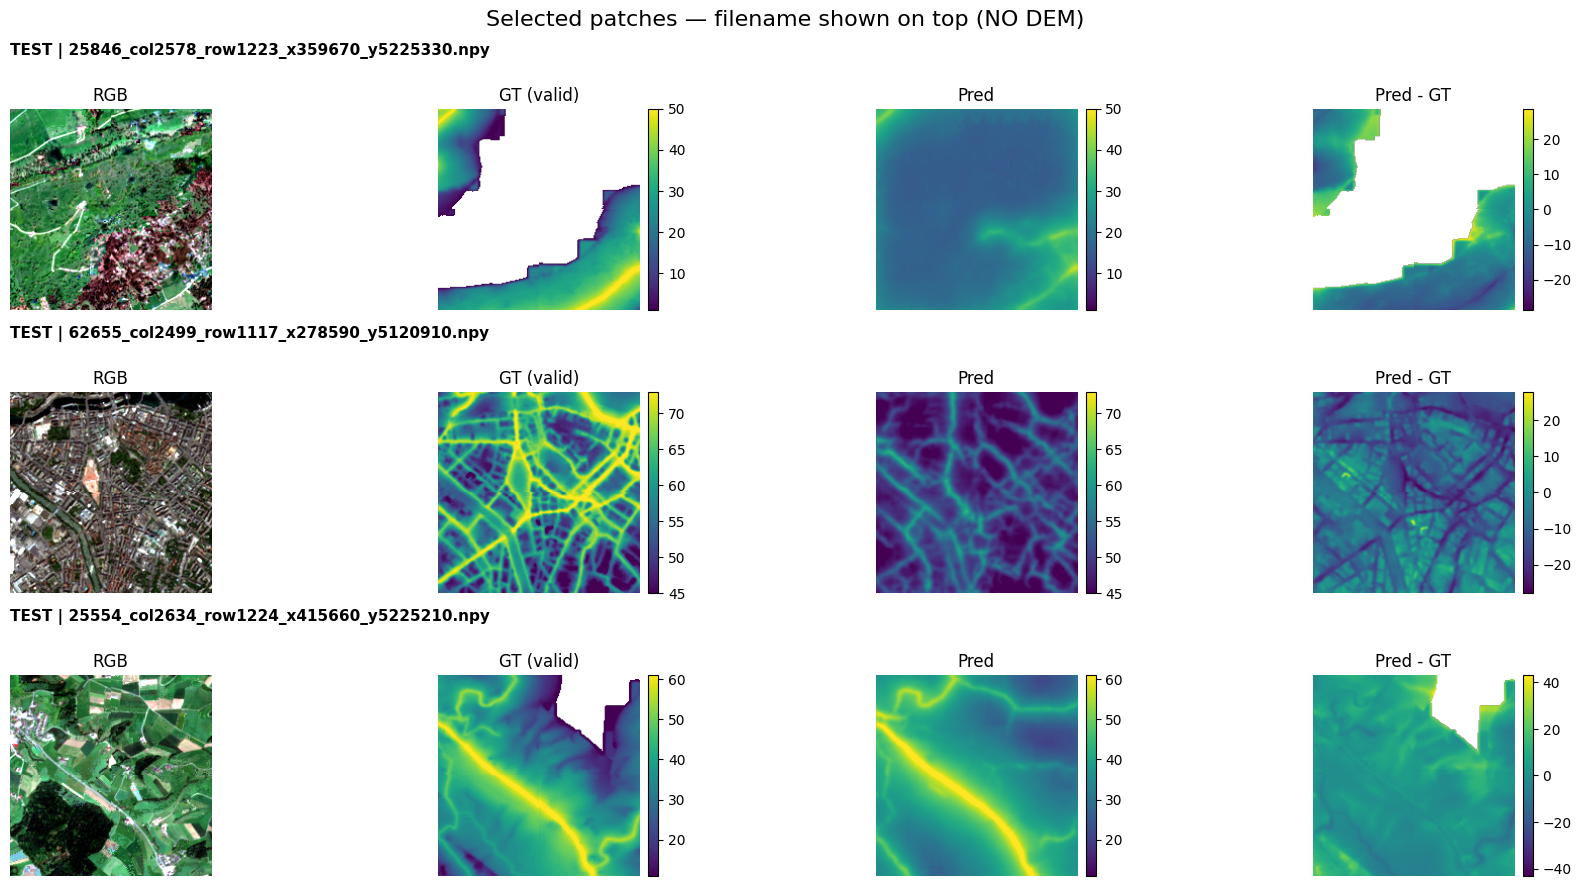

In [4]:
# ============================================================
# 13) VISUALIZE SPECIFIC PATCH FILENAMES (NO-DEM, EVAL-ONLY)
#    Add this section AFTER your model is loaded + stats exist
#    (i.e., after section 9/10/11 in your notebook).
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- your selected patch filenames ---
selected_patch_filenames = [
    "25846_col2578_row1223_x359670_y5225330.npy",
    "62655_col2499_row1117_x278590_y5120910.npy",
    "25554_col2634_row1224_x415660_y5225210.npy",
]

def _norm_name(s):
    return Path(str(s)).name.strip()

# Build quick lookup: filename -> index inside each split dataset
def build_name_to_idx(ds):
    keys = ds.meta["filename"].astype(str).apply(_norm_name).tolist()
    return {k: i for i, k in enumerate(keys)}

val_map  = build_name_to_idx(val_ds)
test_map = build_name_to_idx(test_ds)

def find_in_val_or_test(filename):
    key = _norm_name(filename)
    if key in test_map:
        return "TEST", test_ds, test_map[key]
    if key in val_map:
        return "VAL", val_ds, val_map[key]
    return None, None, None

@torch.no_grad()
def visualize_selected_by_filename_nodem(
    model, filenames, device, x_mean_t, x_std_t,
    title="Selected patches (by filename) — NO DEM"
):
    model.eval()

    rows = []
    missing = []
    for fn in filenames:
        split, ds, idx = find_in_val_or_test(fn)
        if ds is None:
            missing.append(fn)
        else:
            rows.append((fn, split, ds, idx))

    if len(rows) == 0:
        print("❌ None of the requested filenames were found in VAL/TEST.")
        print("Missing:")
        for m in missing:
            print("  -", m)
        return

    n = len(rows)
    fig, axes = plt.subplots(n, 4, figsize=(16, 3*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, (fn_req, split, ds, idx) in enumerate(rows):
        x, y, mask, info = ds[idx]  # info is id/col/row... from your dataset
        xb = x.unsqueeze(0).to(device)

        pred = model(xb).squeeze(0).squeeze(0).detach().cpu().numpy()
        gt   = y.squeeze(0).detach().cpu().numpy()
        mnp  = mask.squeeze(0).detach().cpu().numpy()
        invalid = (mnp < 0.5)

        # RGB
        rgb = denorm_rgb(x, x_mean_t, x_std_t)
        axes[r,0].imshow(rgb)
        axes[r,0].set_title("RGB")
        axes[r,0].axis("off")

        # GT valid-only
        gt_disp = gt.copy()
        gt_disp[invalid] = np.nan
        valid_vals = gt[~invalid]
        if valid_vals.size > 0:
            vmin = np.nanpercentile(valid_vals, 2)
            vmax = np.nanpercentile(valid_vals, 98)
        else:
            vmin, vmax = None, None

        im1 = axes[r,1].imshow(gt_disp, vmin=vmin, vmax=vmax)
        axes[r,1].set_title("GT (valid)")
        axes[r,1].axis("off")
        plt.colorbar(im1, ax=axes[r,1], fraction=0.046, pad=0.04)

        # Pred
        im2 = axes[r,2].imshow(pred, vmin=vmin, vmax=vmax)
        axes[r,2].set_title("Pred")
        axes[r,2].axis("off")
        plt.colorbar(im2, ax=axes[r,2], fraction=0.046, pad=0.04)

        # Error
        err = (pred - gt).copy()
        err[invalid] = np.nan
        max_abs = np.nanmax(np.abs(err))
        evmin, evmax = (-max_abs, max_abs) if np.isfinite(max_abs) and max_abs > 0 else (None, None)

        im3 = axes[r,3].imshow(err, vmin=evmin, vmax=evmax)
        axes[r,3].set_title("Pred - GT")
        axes[r,3].axis("off")
        plt.colorbar(im3, ax=axes[r,3], fraction=0.046, pad=0.04)

        # ✅ filename shown on top (requested)
        fn_key = _norm_name(ds.meta.iloc[idx]["filename"])
        axes[r,0].text(
            0.0, 1.25, f"{split} | {fn_key}",
            transform=axes[r,0].transAxes,
            fontsize=11, fontweight="bold", va="bottom"
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    if missing:
        print("\n⚠️ These filenames were NOT found in VAL/TEST (check spelling or split):")
        for m in missing:
            print("  -", m)

# ---- run it ----
visualize_selected_by_filename_nodem(
    model,
    selected_patch_filenames,
    device=device,
    x_mean_t=x_mean_t,
    x_std_t=x_std_t,
    title="Selected patches — filename shown on top (NO DEM)"
)

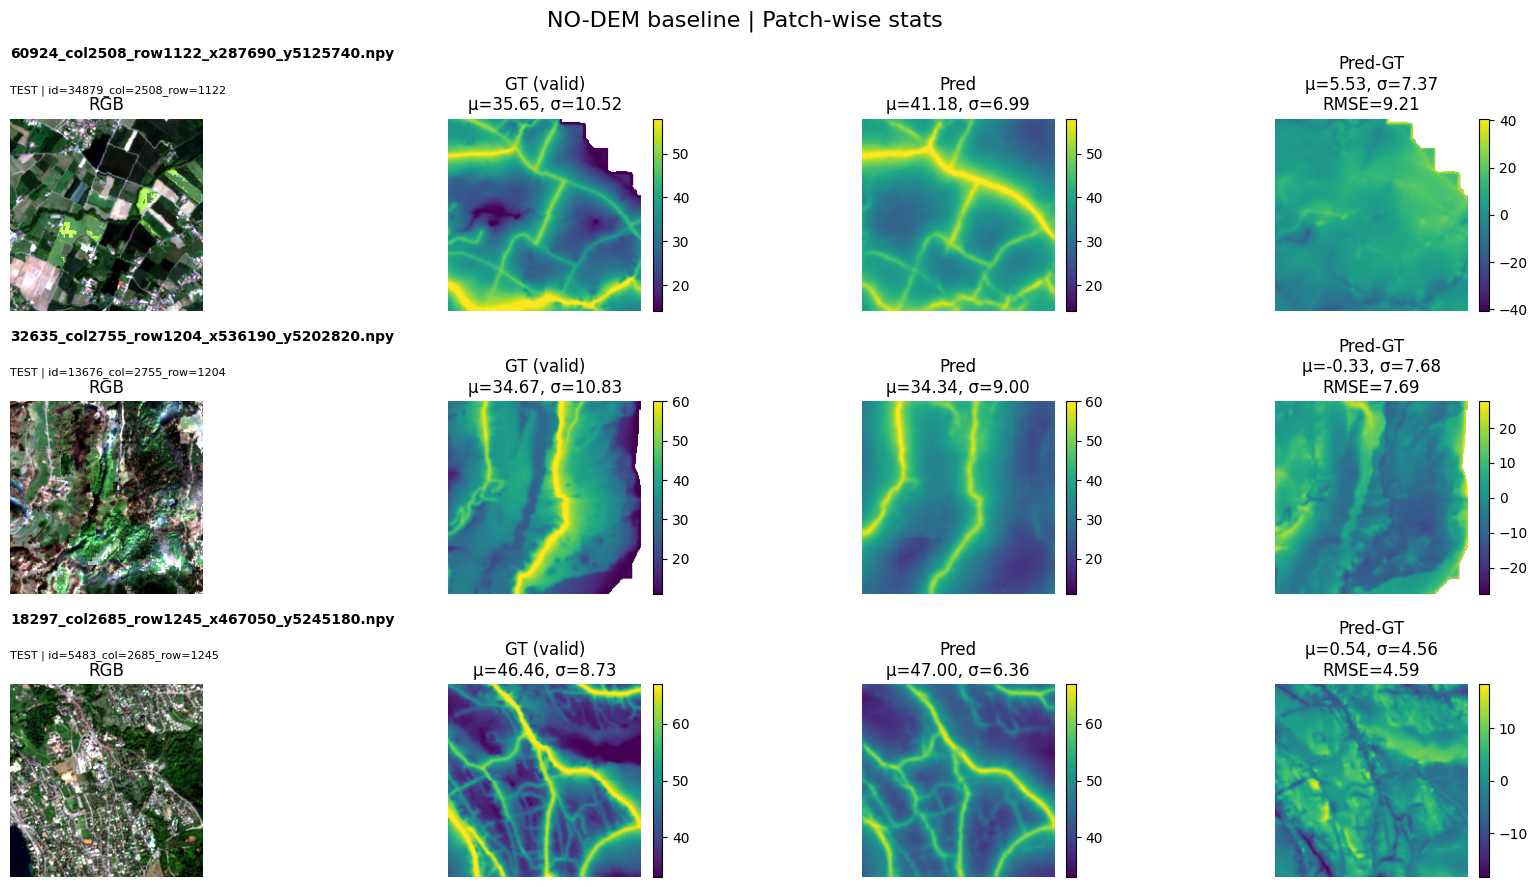


Patch-wise stats (valid GT pixels):
                                  filename split  n_valid     mu_gt  sigma_gt   mu_pred  sigma_pred  mu_pred_gt  sigma_pred_gt     rmse      mae
60924_col2508_row1122_x287690_y5125740.npy  TEST    37166 35.646747 10.522344 41.180242    6.986663    5.533495       7.367879 9.214402 7.373427
32635_col2755_row1204_x536190_y5202820.npy  TEST    39117 34.670246 10.830606 34.340103    9.002867   -0.330143       7.679296 7.686389 6.388335
18297_col2685_row1245_x467050_y5245180.npy  TEST    40000 46.463750  8.730930 46.999190    6.356336    0.535440       4.557757 4.589101 3.646902


In [6]:
# ============================
# PATCH-WISE STATS (NO-DEM baseline)
# ============================

PATCHES_FOR_STATS = [

    "60924_col2508_row1122_x287690_y5125740.npy",
    "32635_col2755_row1204_x536190_y5202820.npy",
    "18297_col2685_row1245_x467050_y5245180.npy",
]

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.amp import autocast

def _norm_name(s):
    return Path(str(s)).name.strip()

def find_in_val_or_test_nodem(filename, val_ds, test_ds):
    key = _norm_name(filename)
    for split_name, ds in [("VAL", val_ds), ("TEST", test_ds)]:
        keys = ds.meta["filename"].astype(str).apply(_norm_name).tolist()
        name_to_idx = {k:i for i,k in enumerate(keys)}
        if key in name_to_idx:
            return ds, name_to_idx[key], split_name
    return None, None, None

def patch_stats_from_maps(gt2d, pred2d, valid2d_bool):
    v = valid2d_bool & np.isfinite(gt2d) & np.isfinite(pred2d)
    n = int(v.sum())
    if n == 0:
        return None

    gt_v = gt2d[v].astype(np.float64)
    pr_v = pred2d[v].astype(np.float64)
    diff = pr_v - gt_v

    return {
        "n_valid": n,
        "mu_gt": float(np.mean(gt_v)),
        "sigma_gt": float(np.std(gt_v, ddof=0)),
        "mu_pred": float(np.mean(pr_v)),
        "sigma_pred": float(np.std(pr_v, ddof=0)),
        "mu_pred_gt": float(np.mean(diff)),
        "sigma_pred_gt": float(np.std(diff, ddof=0)),
        "rmse": float(np.sqrt(np.mean(diff * diff))),
        "mae": float(np.mean(np.abs(diff))),
    }

@torch.no_grad()
def visualize_named_patches_with_stats_nodem(
    model, val_ds, test_ds,
    filenames,
    title="NO-DEM baseline | Patch-wise stats",
    device=device,
    use_amp=use_amp,
    x_mean_t=x_mean_t, x_std_t=x_std_t,
):
    model.eval()

    rows, missing = [], []
    for fn in filenames:
        ds, idx, split_name = find_in_val_or_test_nodem(fn, val_ds, test_ds)
        if ds is None:
            missing.append(fn)
        else:
            rows.append((fn, ds, idx, split_name))

    if len(rows) == 0:
        print("❌ None of requested patches were found in VAL/TEST.")
        if missing:
            print("Missing:", missing)
        return None

    n = len(rows)
    fig, axes = plt.subplots(n, 4, figsize=(16, 3*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    stats_rows = []

    for r, (fn_req, ds, idx, split_name) in enumerate(rows):
        x, y, mask, info = ds[idx]
        xb = x.unsqueeze(0).to(device)

        if use_amp and device.type == "cuda":
            with autocast("cuda"):
                pred_t = model(xb)
        else:
            pred_t = model(xb)

        pred = pred_t.squeeze(0).squeeze(0).detach().cpu().numpy()
        gt   = y.squeeze(0).detach().cpu().numpy()

        # VALID pixels: exactly your baseline GT mask (MASK_ZERO_TARGET=False here)
        valid = (mask.squeeze(0).detach().cpu().numpy() > 0.5) & np.isfinite(pred) & np.isfinite(gt)

        st = patch_stats_from_maps(gt, pred, valid)
        if st is None:
            st = {"n_valid": 0, "mu_gt": np.nan, "sigma_gt": np.nan,
                  "mu_pred": np.nan, "sigma_pred": np.nan,
                  "mu_pred_gt": np.nan, "sigma_pred_gt": np.nan,
                  "rmse": np.nan, "mae": np.nan}

        fn_key = _norm_name(ds.meta.iloc[idx]["filename"])
        stats_rows.append({"filename": fn_key, "split": split_name, **st})

        # ---------- RGB ----------
        rgb = denorm_rgb(x, x_mean_t, x_std_t)
        axes[r,0].imshow(rgb)
        axes[r,0].axis("off")
        axes[r,0].set_title("RGB")

        # ---------- GT (valid only) ----------
        gt_disp = gt.copy()
        gt_disp[~valid] = np.nan

        valid_vals = gt[valid]
        vmin, vmax = (np.nanpercentile(valid_vals, 2), np.nanpercentile(valid_vals, 98)) if valid_vals.size > 0 else (None, None)

        im_gt = axes[r,1].imshow(gt_disp, vmin=vmin, vmax=vmax)
        axes[r,1].axis("off")
        axes[r,1].set_title(f"GT (valid)\nμ={st['mu_gt']:.2f}, σ={st['sigma_gt']:.2f}")
        plt.colorbar(im_gt, ax=axes[r,1], fraction=0.046, pad=0.04)

        # ---------- Pred ----------
        pred_disp = pred.copy()
        pred_disp[~np.isfinite(pred_disp)] = np.nan
        im_pr = axes[r,2].imshow(pred_disp, vmin=vmin, vmax=vmax)
        axes[r,2].axis("off")
        axes[r,2].set_title(f"Pred\nμ={st['mu_pred']:.2f}, σ={st['sigma_pred']:.2f}")
        plt.colorbar(im_pr, ax=axes[r,2], fraction=0.046, pad=0.04)

        # ---------- Diff (Pred-GT) ----------
        diff_map = (pred - gt).copy()
        diff_map[~valid] = np.nan
        max_abs = np.nanmax(np.abs(diff_map))
        dvmin, dvmax = (-max_abs, max_abs) if np.isfinite(max_abs) and max_abs > 0 else (None, None)

        im_df = axes[r,3].imshow(diff_map, vmin=dvmin, vmax=dvmax)
        axes[r,3].axis("off")
        axes[r,3].set_title(f"Pred-GT\nμ={st['mu_pred_gt']:.2f}, σ={st['sigma_pred_gt']:.2f}\nRMSE={st['rmse']:.2f}")
        plt.colorbar(im_df, ax=axes[r,3], fraction=0.046, pad=0.04)

        # ---------- row header ----------
        axes[r,0].text(0.0, 1.30, fn_key, transform=axes[r,0].transAxes,
                       fontsize=10, fontweight="bold", va="bottom")
        axes[r,0].text(0.0, 1.12, f"{split_name} | {info}", transform=axes[r,0].transAxes,
                       fontsize=8, va="bottom")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(stats_rows)
    cols = ["filename","split","n_valid",
            "mu_gt","sigma_gt","mu_pred","sigma_pred",
            "mu_pred_gt","sigma_pred_gt","rmse","mae"]
    df = df[cols]

    print("\nPatch-wise stats (valid GT pixels):")
    print(df.to_string(index=False))

    if missing:
        print("\n⚠️ Not found:")
        for m in missing:
            print(" -", m)

    return df

df_baseline_patch_stats = visualize_named_patches_with_stats_nodem(
    model, val_ds, test_ds,
    PATCHES_FOR_STATS,
    title="NO-DEM baseline | Patch-wise stats",
    device=device,
    use_amp=use_amp,
    x_mean_t=x_mean_t, x_std_t=x_std_t
)

In [8]:
# ============================================================
# 14) SAVE EACH SELECTED PATCH SEPARATELY AS HIGH-RES JPG
#     One JPG per sample: RGB | GT | Pred | Pred-GT
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.amp import autocast

# ----------------------------
# Output folder
# ----------------------------
SAVE_DIR = RUN_DIR / "article_highres_samples_nodem"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving figures to:")
print(SAVE_DIR)

# ----------------------------
# Patches to save
# ----------------------------
PATCHES_TO_SAVE = [
    "60924_col2508_row1122_x287690_y5125740.npy",
    "32635_col2755_row1204_x536190_y5202820.npy",
    "18297_col2685_row1245_x467050_y5245180.npy",
]

# ----------------------------
# Helper: safe filename
# ----------------------------
def safe_stem(filename):
    return Path(filename).stem.replace(".", "_").replace(" ", "_")

# ----------------------------
# Main save function
# ----------------------------
@torch.no_grad()
def save_each_patch_highres_nodem(
    model,
    val_ds,
    test_ds,
    filenames,
    save_dir,
    device=device,
    use_amp=use_amp,
    x_mean_t=x_mean_t,
    x_std_t=x_std_t,
    dpi=500,
):
    model.eval()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    saved_files = []
    missing = []

    for fn in filenames:
        ds, idx, split_name = find_in_val_or_test_nodem(fn, val_ds, test_ds)

        if ds is None:
            missing.append(fn)
            continue

        x, y, mask, info = ds[idx]
        xb = x.unsqueeze(0).to(device)

        if use_amp and device.type == "cuda":
            with autocast("cuda"):
                pred_t = model(xb)
        else:
            pred_t = model(xb)

        pred = pred_t.squeeze(0).squeeze(0).detach().cpu().numpy()
        gt = y.squeeze(0).detach().cpu().numpy()
        valid = (mask.squeeze(0).detach().cpu().numpy() > 0.5) & np.isfinite(pred) & np.isfinite(gt)

        # Statistics
        st = patch_stats_from_maps(gt, pred, valid)
        if st is None:
            st = {
                "mu_gt": np.nan, "sigma_gt": np.nan,
                "mu_pred": np.nan, "sigma_pred": np.nan,
                "mu_pred_gt": np.nan, "sigma_pred_gt": np.nan,
                "rmse": np.nan, "mae": np.nan,
                "n_valid": 0,
            }

        # RGB
        rgb = denorm_rgb(x, x_mean_t, x_std_t)

        # GT valid only
        gt_disp = gt.copy()
        gt_disp[~valid] = np.nan

        valid_vals = gt[valid]
        if valid_vals.size > 0:
            vmin = np.nanpercentile(valid_vals, 2)
            vmax = np.nanpercentile(valid_vals, 98)
        else:
            vmin, vmax = None, None

        # Pred
        pred_disp = pred.copy()
        pred_disp[~np.isfinite(pred_disp)] = np.nan

        # Difference
        diff_map = pred - gt
        diff_map[~valid] = np.nan

        max_abs = np.nanmax(np.abs(diff_map))
        if np.isfinite(max_abs) and max_abs > 0:
            dvmin, dvmax = -max_abs, max_abs
        else:
            dvmin, dvmax = None, None

        # ----------------------------
        # Figure: one row, four panels
        # ----------------------------
        fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))

        # RGB
        axes[0].imshow(rgb)
        axes[0].set_title("RGB", fontsize=11)
        axes[0].axis("off")

        # GT
        im_gt = axes[1].imshow(gt_disp, vmin=vmin, vmax=vmax)
        axes[1].set_title(
            f"GT (valid)\nμ={st['mu_gt']:.2f}, σ={st['sigma_gt']:.2f}",
            fontsize=11
        )
        axes[1].axis("off")
        plt.colorbar(im_gt, ax=axes[1], fraction=0.046, pad=0.04)

        # Pred
        im_pr = axes[2].imshow(pred_disp, vmin=vmin, vmax=vmax)
        axes[2].set_title(
            f"Pred\nμ={st['mu_pred']:.2f}, σ={st['sigma_pred']:.2f}",
            fontsize=11
        )
        axes[2].axis("off")
        plt.colorbar(im_pr, ax=axes[2], fraction=0.046, pad=0.04)

        # Pred - GT
        im_df = axes[3].imshow(diff_map, vmin=dvmin, vmax=dvmax)
        axes[3].set_title(
            f"Pred-GT\nμ={st['mu_pred_gt']:.2f}, σ={st['sigma_pred_gt']:.2f}\nRMSE={st['rmse']:.2f}",
            fontsize=11
        )
        axes[3].axis("off")
        plt.colorbar(im_df, ax=axes[3], fraction=0.046, pad=0.04)

        fn_key = Path(ds.meta.iloc[idx]["filename"]).name

     
        plt.tight_layout()

        out_path = save_dir / f"{safe_stem(fn_key)}_nodem_500dpi.jpg"

        fig.savefig(
            out_path,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.08,
            format="jpg",
            pil_kwargs={"quality": 95}
        )

        plt.close(fig)

        saved_files.append(out_path)
        print(f"✅ Saved: {out_path.name}")

    if missing:
        print("\n⚠️ Missing patches:")
        for m in missing:
            print(" -", m)

    return saved_files


saved_highres_figures = save_each_patch_highres_nodem(
    model=model,
    val_ds=val_ds,
    test_ds=test_ds,
    filenames=PATCHES_TO_SAVE,
    save_dir=SAVE_DIR,
    device=device,
    use_amp=use_amp,
    x_mean_t=x_mean_t,
    x_std_t=x_std_t,
    dpi=500,
)

Saving figures to:
D:\Sunita_Thesis\Datasets\Data_Patches_2km_noDEM\runs_unet_nodem_v2_dropout\article_highres_samples_nodem
✅ Saved: 60924_col2508_row1122_x287690_y5125740_nodem_500dpi.jpg
✅ Saved: 32635_col2755_row1204_x536190_y5202820_nodem_500dpi.jpg
✅ Saved: 18297_col2685_row1245_x467050_y5245180_nodem_500dpi.jpg
